# Estimating Transition Matrices for Grades

## 1. Markov Transition Matrix

A transition matrix, $P$, for a system with $N$ states is an $N \times N$ matrix where each element $P_{ij}$ represents the probability of moving from state $i$ to state $j$ in one step.

### 1.1. Defining the States

- States (N=6): The possible grades are A, B, C, D, E, U.
- The rows of the matrix represent the starting state (Mock Exam Grade).
- The columns of the matrix represent the ending state (Final Exam Grade).

The matrix will look like this:

$$
P = 
\begin{pmatrix}
P_{AA} & P_{AB} & P_{AC} & P_{AD} & P_{AE} & P_{AU} \\
P_{BA} & P_{BB} & P_{BC} & P_{BD} & P_{BE} & P_{BU} \\
P_{CA} & P_{CB} & P_{CC} & P_{CD} & P_{CE} & P_{CU} \\
P_{DA} & P_{DB} & P_{DC} & P_{DD} & P_{DE} & P_{DU} \\
P_{EA} & P_{EB} & P_{EC} & P_{ED} & P_{EE} & P_{EU} \\
P_{UA} & P_{UB} & P_{UC} & P_{UD} & P_{UE} & P_{UU}
\end{pmatrix}
$$

### 1.2. Calculating the Probabilities ($P_{ij}$)

The probability $P_{ij}$ is calculated by observing the number of students who transitioned from grade $i$ (in the Mock) to grade $j$ (in the Final) and dividing it by the total number of students who started with grade $i$.

$$
P_{ij} = \frac{\text{Number of students who got } i \text{ (Mock) and } j \text{ (Final)}}{\text{Total number of students who got } i \text{ (Mock)}}
$$

### 1.3. Key Property

The sum of the probabilities in each row must equal 1, as a student starting in grade $i$ must end up in some grade ($j∈{A,B,C,D,E,U}$).

$$
\sum_{j=A}^{U} P_{ij} = 1 \quad \text{for all } i
$$

## 2. Implementation in Python

### 2.1. Data Setup

In [6]:
import pandas as pd
import numpy as np

# Define the order of the grades (states)
grades = ['A', 'B', 'C', 'D', 'E', 'U']

# --- Example Data Setup (Replace with your actual data) --- the range number is number of students + 1 !!!
data = {
    'StudentID': range(1, 16), 
    'Mock_Grade': ['A', 'A', 'B', 'B', 'B', 'C', 'C', 'D', 'D', 'D', 'E', 'E', 'U', 'U', 'U'],
    'Final_Grade': ['A', 'B', 'A', 'B', 'C', 'B', 'C', 'C', 'D', 'E', 'D', 'E', 'E', 'U', 'U']
}
df = pd.DataFrame(data)
# -----------------------------------------------------------

### 2.2. Counting the Transitions (The Joint Frequencies)

In [4]:
# 1. Create a contingency table (counts)
# Index = Mock_Grade (Start State)
# Columns = Final_Grade (End State)
transition_counts = pd.crosstab(
    df['Mock_Grade'],
    df['Final_Grade'],
    dropna=False # Important to include all pairs if data has missing categories
)

# Optional: Reindex to ensure all grades are present and in the correct order
transition_counts = transition_counts.reindex(index=grades, columns=grades, fill_value=0)

print("--- Transition Counts (Frequency Table) ---")
print(transition_counts)

--- Transition Counts (Frequency Table) ---
Final_Grade  A  B  C  D  E  U
Mock_Grade                   
A            1  1  0  0  0  0
B            1  1  1  0  0  0
C            0  1  1  0  0  0
D            0  0  1  1  1  0
E            0  0  0  1  1  0
U            0  0  0  0  1  2


### 2.3. Calculating the Transition Matrix (The Probabilities)

In [5]:
# 2. Convert counts to probabilities (Transition Matrix P)
# The margins=True argument adds the row sums for verification
transition_matrix_P = pd.crosstab(
    df['Mock_Grade'],
    df['Final_Grade'],
    normalize='index', # Normalizes by row sum to get probabilities
    dropna=False
)

# Optional: Reindex and fill again to ensure a complete, ordered matrix
transition_matrix_P = transition_matrix_P.reindex(index=grades, columns=grades, fill_value=0)

# Optional: Format the probabilities for better readability
transition_matrix_P_formatted = transition_matrix_P.apply(lambda x: pd.Series([f'{v:.3f}' for v in x], index=x.index), axis=1)

print("\n--- Markov Transition Matrix P (Probabilities) ---")
print(transition_matrix_P_formatted)


--- Markov Transition Matrix P (Probabilities) ---
Final_Grade      A      B      C      D      E      U
Mock_Grade                                           
A            0.500  0.500  0.000  0.000  0.000  0.000
B            0.333  0.333  0.333  0.000  0.000  0.000
C            0.000  0.500  0.500  0.000  0.000  0.000
D            0.000  0.000  0.333  0.333  0.333  0.000
E            0.000  0.000  0.000  0.500  0.500  0.000
U            0.000  0.000  0.000  0.000  0.333  0.667


This transition matrix can then be used to predict the expected grade distribution in the final exam, given the distribution in the mock exam, by using the matrix multiplication: 

$$
\text{Final\_Distribution} = \text{Mock\_Distribution} \times P
$$




## 3. The entire code in one block

In [7]:
import pandas as pd
import numpy as np

# Define the order of the grades (states)
grades = ['A', 'B', 'C', 'D', 'E', 'U']

# --- Not Observed Example Data Setup (Replace with your actual data) --- the range number is number of students + 1 !!!
data = {
    'StudentID': range(1, 16), 
    'Mock_Grade': ['A', 'A', 'B', 'B', 'B', 'C', 'C', 'D', 'D', 'D', 'E', 'E', 'U', 'U', 'U'],
    'Final_Grade': ['A', 'B', 'A', 'B', 'C', 'B', 'C', 'C', 'D', 'E', 'D', 'E', 'E', 'U', 'U']
}
df = pd.DataFrame(data)
# -----------------------------------------------------------




# 1. Create a contingency table (counts)
# Index = Mock_Grade (Start State)
# Columns = Final_Grade (End State)
transition_counts = pd.crosstab(
    df['Mock_Grade'],
    df['Final_Grade'],
    dropna=False # Important to include all pairs if data has missing categories
)

# Optional: Reindex to ensure all grades are present and in the correct order
transition_counts = transition_counts.reindex(index=grades, columns=grades, fill_value=0)

print("--- Transition Counts (Frequency Table) ---")
print(transition_counts)




# 2. Convert counts to probabilities (Transition Matrix P)
# The margins=True argument adds the row sums for verification
transition_matrix_P = pd.crosstab(
    df['Mock_Grade'],
    df['Final_Grade'],
    normalize='index', # Normalizes by row sum to get probabilities
    dropna=False
)

# Optional: Reindex and fill again to ensure a complete, ordered matrix
transition_matrix_P = transition_matrix_P.reindex(index=grades, columns=grades, fill_value=0)

# Optional: Format the probabilities for better readability
transition_matrix_P_formatted = transition_matrix_P.apply(lambda x: pd.Series([f'{v:.3f}' for v in x], index=x.index), axis=1)

print("\n--- Markov Transition Matrix P (Probabilities) ---")
print(transition_matrix_P_formatted)




--- Transition Counts (Frequency Table) ---
Final_Grade  A  B  C  D  E  U
Mock_Grade                   
A            1  1  0  0  0  0
B            1  1  1  0  0  0
C            0  1  1  0  0  0
D            0  0  1  1  1  0
E            0  0  0  1  1  0
U            0  0  0  0  1  2

--- Markov Transition Matrix P (Probabilities) ---
Final_Grade      A      B      C      D      E      U
Mock_Grade                                           
A            0.500  0.500  0.000  0.000  0.000  0.000
B            0.333  0.333  0.333  0.000  0.000  0.000
C            0.000  0.500  0.500  0.000  0.000  0.000
D            0.000  0.000  0.333  0.333  0.333  0.000
E            0.000  0.000  0.000  0.500  0.500  0.000
U            0.000  0.000  0.000  0.000  0.333  0.667



--- Transition Counts (frequency table) ---


2_Grade,A,B,C,D,E,U
1_Grade,,,,,,
A,2,0,0,0,0,0
B,0,6,9,2,0,0
C,0,1,1,5,0,0
D,0,0,2,3,2,2
E,0,1,1,1,1,3
U,0,0,0,0,0,0



--- Markov Transition Matrix P (probabilities, formatted) ---


2_Grade,A,B,C,D,E,U
1_Grade,,,,,,
A,1.000,0.000,0.000,0.000,0.000,0.000
B,0.000,0.353,0.529,0.118,0.000,0.000
C,0.000,0.143,0.143,0.714,0.000,0.000
D,0.000,0.000,0.222,0.333,0.222,0.222
E,0.000,0.143,0.143,0.143,0.143,0.429
U,0.000,0.000,0.000,0.000,0.000,0.000



--- Markov Transition Matrix P (numeric, styled) ---


2_Grade,A,B,C,D,E,U
1_Grade,,,,,,
A,1.000,0.000,0.000,0.000,0.000,0.000
B,0.000,0.353,0.529,0.118,0.000,0.000
C,0.000,0.143,0.143,0.714,0.000,0.000
D,0.000,0.000,0.222,0.333,0.222,0.222
E,0.000,0.143,0.143,0.143,0.143,0.429
U,0.000,0.000,0.000,0.000,0.000,0.000


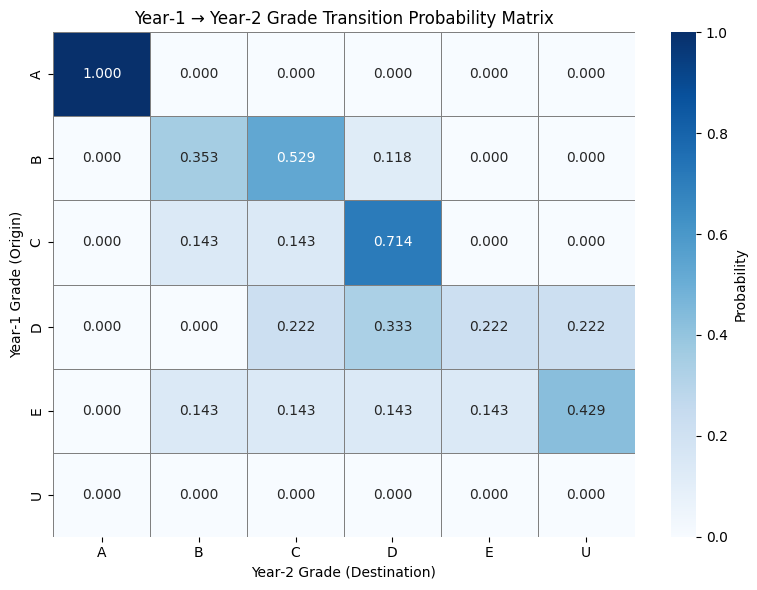


Numeric transition matrix saved to 'transition_matrix.csv'


In [21]:
# -------------------------------------------------
# 1️⃣  Imports
# -------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------
# 2️⃣  Raw grade data (both lists must be the same length)
# -------------------------------------------------
grades_1 = [
    'E','B','B','C','C','B','B','B','C','E','C','C','A','D','D',
    'C','B','B','E','E','C','A','E','D','D','D','B','B','D',
    'D','D','B','B','D','B','B','E','B','B','B','B','E'
]

grades_2 = [
    'B','C','B','D','D','D','C','C','D','E','C','D','A','C','U',
    'B','C','C','U','C','D','A','U','D','D','D','B','B','U',
    'E','E','B','C','C','C','C','U','C','B','B','D','D'
]

assert len(grades_1) == len(grades_2) == 42, "Lists must be equal length"

# -------------------------------------------------
# 3️⃣  Build DataFrame
# -------------------------------------------------
df = pd.DataFrame({
    "1_Grade": grades_1,
    "2_Grade": grades_2
})

# Clean – upper‑case everything
df["1_Grade"] = df["1_Grade"].str.upper().str.strip()
df["2_Grade"] = df["2_Grade"].str.upper().str.strip()

# -------------------------------------------------
# 4️⃣  Define the full set of states (ordered)
# -------------------------------------------------
states = ['A', 'B', 'C', 'D', 'E', 'U']

# -------------------------------------------------
# 5️⃣  Transition counts (raw frequencies)
# -------------------------------------------------
transition_counts = pd.crosstab(df["1_Grade"], df["2_Grade"], dropna=False)
transition_counts = transition_counts.reindex(index=states,
                                             columns=states,
                                             fill_value=0)

print("\n--- Transition Counts (frequency table) ---")
display(transition_counts)

# -------------------------------------------------
# 6️⃣  Transition probabilities (row‑wise)
# -------------------------------------------------
transition_matrix = pd.crosstab(df["1_Grade"],
                               df["2_Grade"],
                               normalize='index',
                               dropna=False)

transition_matrix = transition_matrix.reindex(index=states,
                                            columns=states,
                                            fill_value=0)

# ----- Formatting option 1 (pure pandas, no warning) -----
transition_pretty = transition_matrix.map(lambda x: f"{x:.3f}")

print("\n--- Markov Transition Matrix P (probabilities, formatted) ---")
display(transition_pretty)

# ----- Formatting option 2 (keep numeric, style for display) -----
print("\n--- Markov Transition Matrix P (numeric, styled) ---")
display(transition_matrix.style.format("{:.3f}"))

# -------------------------------------------------
# 7️⃣  Heatmap of the probability matrix
# -------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    transition_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar_kws={'label': 'Probability'},
    linewidths=.5,
    linecolor='gray'
)

plt.title("Year‑1 → Year‑2 Grade Transition Probability Matrix")
plt.xlabel("Year‑2 Grade (Destination)")
plt.ylabel("Year‑1 Grade (Origin)")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 8️⃣  (Optional) Save the numeric matrix for later use
# -------------------------------------------------
transition_matrix.to_csv("transition_matrix.csv")
print("\nNumeric transition matrix saved to 'transition_matrix.csv'")

## 4. Procedure that uses percentages instead of grades


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import norm   # <-- new import

# Generate synthetic data in order to test the code
def generate_results(
    n_rows: int = 10_000,
    seed: int | None = 42,
    correlation: float = 0.3,
) -> pd.DataFrame:
    """
    Generate a synthetic two‑year result table.

    Parameters
    ----------
    n_rows : int
        Number of observations (rows) to create.
    seed : int | None
        Random seed for reproducibility. Set to None for fully random.
    correlation : float
        Desired Pearson correlation between Year‑1 and Year‑2 percentages.
        Must be between -1 and 1. 0 gives independent columns,
        positive values give a tendency for the second year to follow the first.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['Year_1_Result', 'Year_2_Result'] containing
        percentages (float, 0‑100).
    """
    rng = np.random.default_rng(seed)

    # Year‑1 percentages uniformly distributed between 0 and 100
    year1 = rng.uniform(0, 100, size=n_rows)

    # Build a bivariate normal with the requested correlation
    cov = [[1, correlation],
           [correlation, 1]]
    z = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_rows)

    # Convert the second normal margin to a uniform [0,100] using the Gaussian CDF
    # norm.cdf returns Φ(x) ∈ (0,1); multiplying by 100 gives a percentage.
    year2 = 100 * norm.cdf(z[:, 1])   # <-- fixed line

    # Assemble the DataFrame
    df = pd.DataFrame({
        "Year_1_Result": year1,
        "Year_2_Result": year2,
    })

    return df.round(1)


if __name__ == "__main__":
    # Example usage
    synthetic_df = generate_results(n_rows=10_000, correlation=0.4)
    print(synthetic_df.head())

    # Save to CSV if you need a file to feed into other scripts
    synthetic_df.to_csv("synthetic_two_year_results.csv", index=False)

   Year_1_Result  Year_2_Result
0           77.4           98.6
1           43.9           10.6
2           85.9           28.9
3           69.7           20.3
4            9.4            7.8


In [17]:
# -------------------------------------------------
# 1️⃣  Imports (run once)
# -------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------
# 2️⃣  Load the CSV that you already saved
# -------------------------------------------------
csv_path = "synthetic_two_year_results.csv"   # adjust if the file lives elsewhere
df = pd.read_csv(csv_path)

# Quick sanity check
print("First few rows of the raw data:")
display(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

First few rows of the raw data:


,Year_1_Result,Year_2_Result
0,77.4,98.6
1,43.9,10.6
2,85.9,28.9
3,69.7,20.3
4,9.4,7.8



Shape: (10000, 2)

Columns: ['Year_1_Result', 'Year_2_Result']


###  4.1. Load csv data and define the size of the bins

In [10]:
# -------------------------------------------------
# 3️⃣  Choose binning strategy
# -------------------------------------------------
bin_width = 10                     # 0‑9, 10‑19, …, 90‑99  (change if you want finer/coarser)
bins = np.arange(0, 101, bin_width)   # edges: 0,10,20,…,100
labels = [f"{int(b)}‑{int(b+bin_width-1)}" for b in bins[:-1]]

# Assign each observation to a bin (left‑inclusive, right‑exclusive)
df["Y1_bin"] = pd.cut(df["Year_1_Result"],
                      bins=bins,
                      right=False,
                      labels=labels)

df["Y2_bin"] = pd.cut(df["Year_2_Result"],
                      bins=bins,
                      right=False,
                      labels=labels)

print("\nBinned preview (first 5 rows):")
display(df[["Year_1_Result","Y1_bin","Year_2_Result","Y2_bin"]].head())


Binned preview (first 5 rows):


,Year_1_Result,Y1_bin,Year_2_Result,Y2_bin
0,77.4,70‑79,98.6,90‑99
1,43.9,40‑49,10.6,10‑19
2,85.9,80‑89,28.9,20‑29
3,69.7,60‑69,20.3,20‑29
4,9.4,0‑9,7.8,0‑9


### 4.2. Build the transition-count matrix

In [11]:
# -------------------------------------------------
# 4️⃣  Build the raw transition‑count matrix
# -------------------------------------------------
raw_counts = pd.crosstab(df["Y1_bin"], df["Y2_bin"])

print("\nRaw transition counts (rows = Year‑1 bin, columns = Year‑2 bin):")
display(raw_counts)


Raw transition counts (rows = Year‑1 bin, columns = Year‑2 bin):


Y2_bin,0‑9,10‑19,20‑29,30‑39,40‑49,50‑59,60‑69,70‑79,80‑89,90‑99
Y1_bin,,,,,,,,,,
0‑9,115,103,91,108,113,77,92,90,100,86
10‑19,114,103,111,120,100,100,100,117,101,85
20‑29,101,104,97,113,96,112,93,93,111,90
30‑39,102,108,93,95,95,109,95,100,95,97
40‑49,101,100,106,111,84,122,88,87,92,88
50‑59,94,103,99,129,107,89,96,90,99,121
60‑69,102,104,105,102,93,94,104,94,110,105
70‑79,83,89,91,104,126,115,87,77,100,119
80‑89,96,93,90,90,114,120,90,105,76,93


### 4.3. Convert the transition-count into probabilities

In [12]:
# -------------------------------------------------
# 5️⃣  Convert counts → row‑wise probabilities (the transition matrix)
# -------------------------------------------------
transition_matrix = raw_counts.div(raw_counts.sum(axis=1), axis=0).fillna(0)

print("\nTransition matrix (probabilities, rounded to 3 dp):")
display(transition_matrix.round(3))


Transition matrix (probabilities, rounded to 3 dp):


Y2_bin,0‑9,10‑19,20‑29,30‑39,40‑49,50‑59,60‑69,70‑79,80‑89,90‑99
Y1_bin,,,,,,,,,,
0‑9,0.118,0.106,0.093,0.111,0.116,0.079,0.094,0.092,0.103,0.088
10‑19,0.108,0.098,0.106,0.114,0.095,0.095,0.095,0.111,0.096,0.081
20‑29,0.100,0.103,0.096,0.112,0.095,0.111,0.092,0.092,0.110,0.089
30‑39,0.103,0.109,0.094,0.096,0.096,0.110,0.096,0.101,0.096,0.098
40‑49,0.103,0.102,0.108,0.113,0.086,0.125,0.090,0.089,0.094,0.090
50‑59,0.092,0.100,0.096,0.126,0.104,0.087,0.093,0.088,0.096,0.118
60‑69,0.101,0.103,0.104,0.101,0.092,0.093,0.103,0.093,0.109,0.104
70‑79,0.084,0.090,0.092,0.105,0.127,0.116,0.088,0.078,0.101,0.120
80‑89,0.099,0.096,0.093,0.093,0.118,0.124,0.093,0.109,0.079,0.096


### 4.4. Visualize the matrix as heatmap

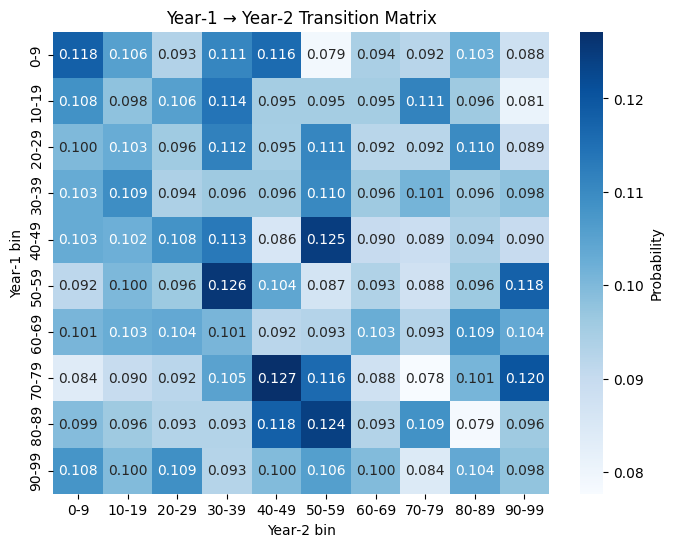

In [13]:
# -------------------------------------------------
# 6️⃣  OPTIONAL: visualise the matrix as a heatmap
# -------------------------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(transition_matrix,
            annot=True,
            fmt=".3f",
            cmap="Blues",
            cbar_kws={'label': 'Probability'})
plt.title("Year‑1 → Year‑2 Transition Matrix")
plt.xlabel("Year‑2 bin")
plt.ylabel("Year‑1 bin")
plt.show()

In [14]:
# -------------------------------------------------
# 7️⃣  OPTIONAL: one‑step forecast using the matrix
# -------------------------------------------------
# Empirical start distribution (proportion of observations in each Year‑1 bin)
start_dist = raw_counts.sum(axis=1) / raw_counts.values.sum()

# Predicted distribution after one year:
next_year_dist = start_dist @ transition_matrix.values

print("\nStart distribution (proportion of students in each Year‑1 bin):")
display(start_dist.round(3))

print("\nPredicted distribution for Year‑2 (after applying the transition matrix):")
display(pd.Series(next_year_dist, index=labels).round(3))


Start distribution (proportion of students in each Year‑1 bin):


Y1_bin
0‑9      0.098
10‑19    0.105
20‑29    0.101
30‑39    0.099
40‑49    0.098
50‑59    0.103
60‑69    0.101
70‑79    0.099
80‑89    0.097
90‑99    0.098
dtype: float64


Predicted distribution for Year‑2 (after applying the transition matrix):


0‑9      0.102
10‑19    0.101
20‑29    0.099
30‑39    0.106
40‑49    0.103
50‑59    0.104
60‑69    0.094
70‑79    0.094
80‑89    0.099
90‑99    0.098
dtype: float64

In [15]:
# -------------------------------------------------
# 8️⃣  OPTIONAL: save the transition matrix for later reuse
# -------------------------------------------------
transition_matrix.to_csv("transition_matrix.csv")
print("\nTransition matrix saved to 'transition_matrix.csv'")


Transition matrix saved to 'transition_matrix.csv'
